### Principal component analysis (PCA)

1. Load or create a dataset with more than 2 dimensions.
2. Find the first 2 principal components with and without using sklearn.
3. Practice using PCA to preserve a certain percentage of variance.
4. Train a classification or regression neural network by using: 
- a) The Original dataset
- b) Principal components

5. Repeat part 4 using Kernel PCA (linear, sigmoid, RBF).
6. Build a pipeline to tune the hyperparameters of Kernel PCA and also the neural network. Which
hyperparameters can be tuned?

2D means that the dataset has 2 or more featurs/colums per sample

In [1]:
# lets create some cluster blobs for a 2D dataset

from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X,y = make_blobs(n_samples=300, # number of points
                n_features=2,   # the dimension
                centers=4,      # number of cluster centers generated
                cluster_std=1.4,# the spread of the clusters
                random_state=42)# seed



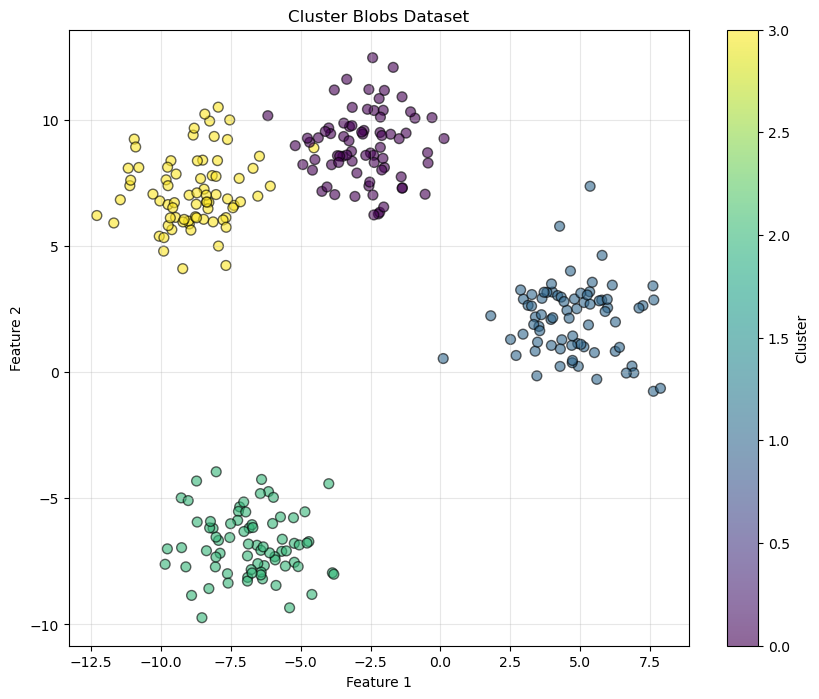

In [2]:
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.6, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Cluster Blobs Dataset')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
# PCA principa component analysis linear dimenson-reduction method
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)
print(pca2.explained_variance_ratio_)
print("total variance",pca2.explained_variance_ratio_.sum())

pca95 = PCA(n_components=0.95) # preserve 95% of the data
X_pca95 = pca95.fit_transform(X)
print("asd",pca95.n_components_)
print("total variance",pca95.explained_variance_ratio_.sum())
print(f"seems like we find {pca95.n_components_} PCs becouse there only are {pca95.n_components_} ")
print("increaseing the amount of diemnsions to 5 will increase the amount of componetns to 3,\n but since we are only using 2 and finding 2 means that we are finding all the diemnsion \nof the data ")

[0.58117062 0.41882938]
total variance 1.0
asd 2
total variance 1.0
seems like we find 2 PCs becouse there only are 2 
increaseing the amount of diemnsions to 5 will increase the amount of componetns to 3,
 but since we are only using 2 and finding 2 means that we are finding all the diemnsion 
of the data 


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# split the data simillar to intro course
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# normalize it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# A ) train on the original dataset
model_OG = Sequential([
    Dense(16, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dense(8,activation='relu'),
    Dense(4,activation='softmax'),
])
model_OG.compile(optimizer=Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
hist_OG = model_OG.fit(X_train_scaled,y_train,epochs=50,batch_size=32,validation_split=0.2,verbose=2)




Epoch 1/50
6/6 - 0s - loss: 1.4795 - accuracy: 0.2292 - val_loss: 1.4545 - val_accuracy: 0.1875
Epoch 2/50
6/6 - 0s - loss: 1.4412 - accuracy: 0.2500 - val_loss: 1.4193 - val_accuracy: 0.2708
Epoch 3/50
6/6 - 0s - loss: 1.4064 - accuracy: 0.3906 - val_loss: 1.3872 - val_accuracy: 0.4792
Epoch 4/50
6/6 - 0s - loss: 1.3747 - accuracy: 0.4792 - val_loss: 1.3571 - val_accuracy: 0.5208
Epoch 5/50
6/6 - 0s - loss: 1.3454 - accuracy: 0.4844 - val_loss: 1.3278 - val_accuracy: 0.5417
Epoch 6/50
6/6 - 0s - loss: 1.3140 - accuracy: 0.4948 - val_loss: 1.2995 - val_accuracy: 0.5625
Epoch 7/50
6/6 - 0s - loss: 1.2887 - accuracy: 0.4948 - val_loss: 1.2737 - val_accuracy: 0.5625
Epoch 8/50
6/6 - 0s - loss: 1.2639 - accuracy: 0.4948 - val_loss: 1.2503 - val_accuracy: 0.5625
Epoch 9/50
6/6 - 0s - loss: 1.2419 - accuracy: 0.5417 - val_loss: 1.2290 - val_accuracy: 0.6042
Epoch 10/50
6/6 - 0s - loss: 1.2207 - accuracy: 0.6198 - val_loss: 1.2079 - val_accuracy: 0.6667
Epoch 11/50
6/6 - 0s - loss: 1.1989 - a

In [5]:
# B )

import numpy as np

# center data
X_train_centered = X_train - X_train.mean(axis=0)
X_test_centered = X_test - X_test.mean(axis=0)

# SVD on covariance (or directly on centered data)
U, S, Vt = np.linalg.svd(X_train_centered / np.sqrt(X_train_centered.shape[0]-1), full_matrices=False)

# columns of V = principal axes; S^2 = variances along PCs
explained_variance = S**2
explained_variance_ratio = explained_variance / explained_variance.sum()

# first 2 PCs and projections
components_2 = Vt[:2]


# .T betyder transpose
# @ means matrix multiplication since python 3.5
X_train_manual_PCA = X_train_centered @ components_2.T
X_test_manual_PCA = X_test_centered @ components_2.T


model_PCA = Sequential([
      Dense(16, activation='relu', input_dim=2),
    Dense(8,activation='relu'),
    Dense(4,activation='softmax'),
])

model_PCA.compile(optimizer=Adam(learning_rate=0.001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

hist_PCA = model_PCA.fit(X_train_manual_PCA,y_train,
                        epochs=50,
                        batch_size=32,
                        validation_split=.02,
                        verbose=2)

Epoch 1/50
8/8 - 0s - loss: 1.5654 - accuracy: 0.7234 - val_loss: 1.4551 - val_accuracy: 0.8000
Epoch 2/50
8/8 - 0s - loss: 1.3887 - accuracy: 0.7447 - val_loss: 1.2965 - val_accuracy: 0.8000
Epoch 3/50
8/8 - 0s - loss: 1.2485 - accuracy: 0.7362 - val_loss: 1.1833 - val_accuracy: 0.8000
Epoch 4/50
8/8 - 0s - loss: 1.1313 - accuracy: 0.7362 - val_loss: 1.0951 - val_accuracy: 0.8000
Epoch 5/50
8/8 - 0s - loss: 1.0369 - accuracy: 0.7404 - val_loss: 1.0235 - val_accuracy: 0.8000
Epoch 6/50
8/8 - 0s - loss: 0.9582 - accuracy: 0.7447 - val_loss: 0.9626 - val_accuracy: 0.8000
Epoch 7/50
8/8 - 0s - loss: 0.8829 - accuracy: 0.7489 - val_loss: 0.9056 - val_accuracy: 0.8000
Epoch 8/50
8/8 - 0s - loss: 0.8166 - accuracy: 0.7489 - val_loss: 0.8514 - val_accuracy: 0.8000
Epoch 9/50
8/8 - 0s - loss: 0.7567 - accuracy: 0.7532 - val_loss: 0.8001 - val_accuracy: 0.8000
Epoch 10/50
8/8 - 0s - loss: 0.7008 - accuracy: 0.7532 - val_loss: 0.7540 - val_accuracy: 0.8000
Epoch 11/50
8/8 - 0s - loss: 0.6524 - a

example of usage of @ operator


In [6]:
import numpy as np
arr1 = np.array([1,1,1])
arr2 = np.array([2,2,2])
res = arr1 @ arr2
print(res)

6


In [7]:
print("Original accuracy:", model_OG.evaluate(X_test_scaled, y_test)[1])
print("PCA accuracy:", model_PCA.evaluate(X_test_manual_PCA, y_test)[1])


2/2 [==============================] - 0s 1ms/step - loss: 0.2433 - accuracy: 0.9833
Original accuracy: 0.9833333492279053
2/2 [==============================] - 0s 1ms/step - loss: 0.2897 - accuracy: 0.9667
PCA accuracy: 0.9666666388511658


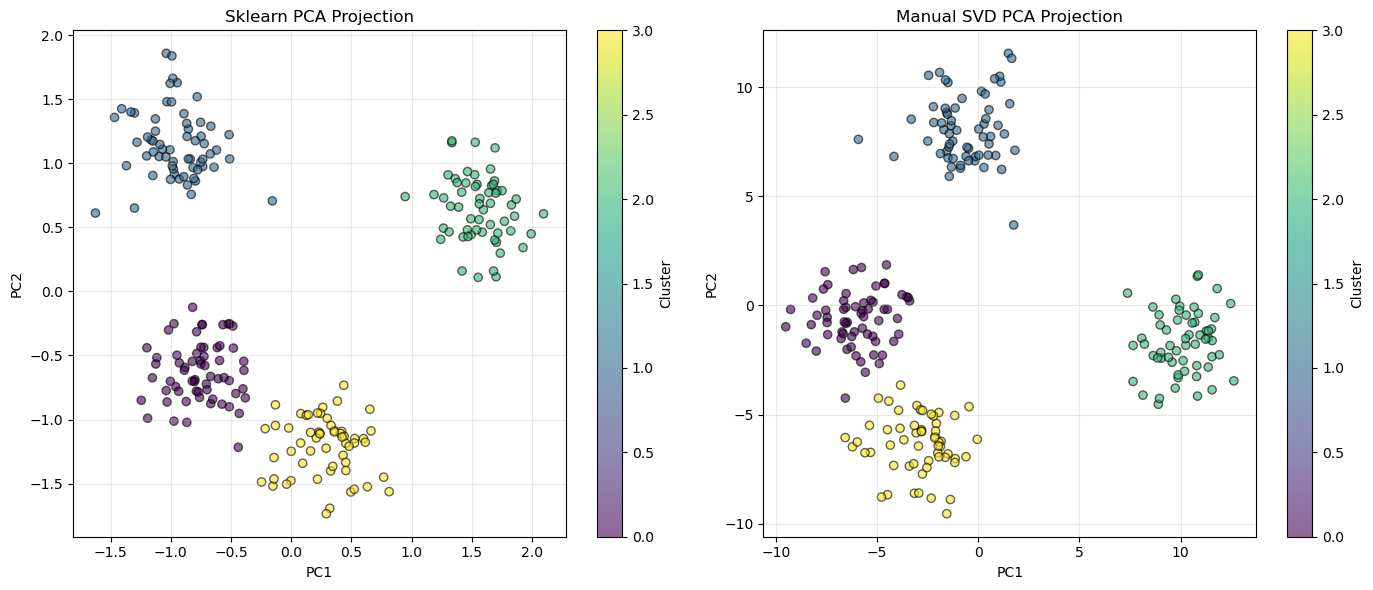

the manual and not give the same result,both have clusters that are seperable


In [8]:
plt.figure(figsize=(14, 6))

# Plot sklearn PCA (if you have it)
plt.subplot(1, 2, 1)
pca_sklearn = PCA(n_components=2)
X_train_sklearn_PCA = pca_sklearn.fit_transform(X_train_scaled)
plt.scatter(X_train_sklearn_PCA[:, 0], X_train_sklearn_PCA[:, 1], c=y_train, cmap='viridis', alpha=0.6, edgecolors='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Sklearn PCA Projection')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)

# Plot manual PCA
plt.subplot(1, 2, 2)
plt.scatter(X_train_manual_PCA[:, 0], X_train_manual_PCA[:, 1], c=y_train, cmap='viridis', alpha=0.6, edgecolors='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Manual SVD PCA Projection')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("the manual and not give the same result,both have clusters that are seperable")

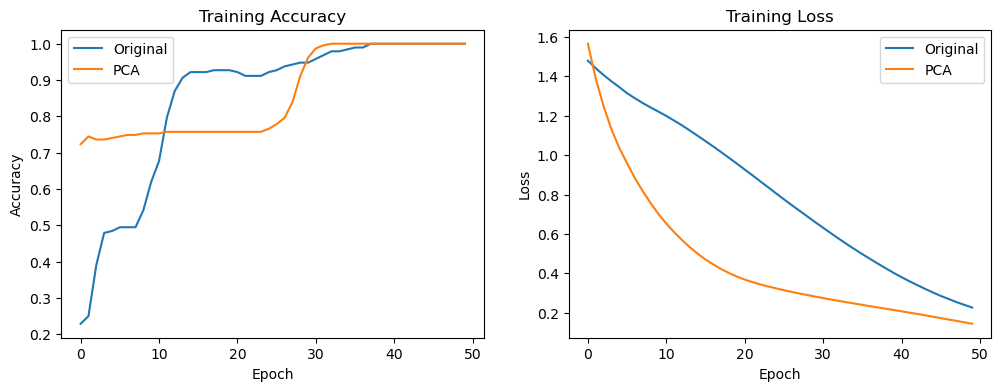

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_OG.history['accuracy'], label='Original')
plt.plot(hist_PCA.history['accuracy'], label='PCA')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')

plt.subplot(1, 2, 2)
plt.plot(hist_OG.history['loss'], label='Original')
plt.plot(hist_PCA.history['loss'], label='PCA')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

Classification problem
1. Load IRIS and MNIST fashion datasets from Keras.
2. Build and train a neural network for classifying the loaded labeled datasets.
3. Tune the hyperparameters (including hidden layer size and activation functions). What else can be tuned?
4. Plot the loss and accuracy for training and testing datasets.
5. Save the weights of the layers and use callbacks during the training process.
6. Practice saving and loading the trained model.

In [10]:
from tensorflow.keras.datasets import mnist
from sklearn.datasets import load_iris

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint




In [12]:
(x_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [13]:
gray_scale = 255
x_train = x_train.astype('float32') / gray_scale
X_test = X_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", X_test.shape)
print("Target matrix (y_test):", y_test.shape)

Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


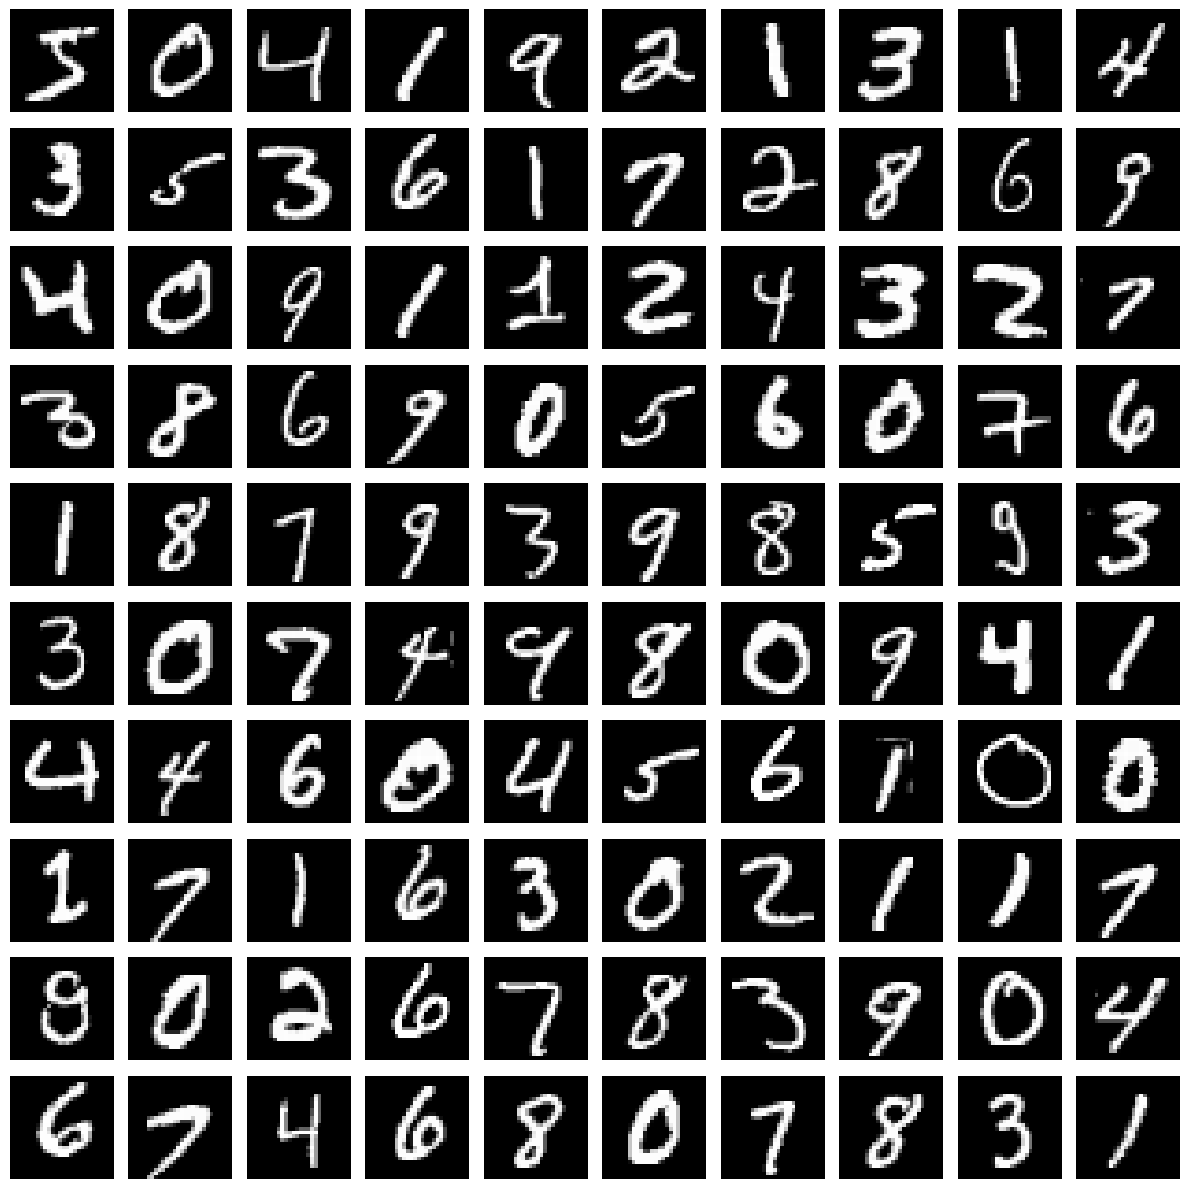

In [14]:

fig, ax = plt.subplots(10, 10, figsize=(12, 12))
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k], cmap='gray')
        ax[i][j].axis('off')
        k += 1
plt.tight_layout()
plt.show()

In [15]:
Tuning = [
    {'hidden1':128,'hidden2':64,'activation':'relu','learning_rate':0.001 },
    {'hidden1':256,'hidden2':128,'activation':'sigmoid','learning_rate':0.0005 },
    {'hidden1':512,'hidden2':256,'activation':'tanh','learning_rate':0.0001 },
]

In [16]:
results = []
for Tunes in Tuning:
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(Tunes['hidden1'],activation=Tunes['activation']),
        Dense(Tunes['hidden2'],activation=Tunes['activation']),
        Dense(10,activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=Tunes['learning_rate']),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    train_model = model.fit(x_train,y_train,
                            epochs=10,
                            validation_split=.2,
                            verbose=2)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    results.append({
        'Tunes': Tunes,
        'test_accuracy': test_acc,
        'test_loss': test_loss
    })

    print(f"Config: {Tunes} → Accuracy: {test_acc:.4f}")
# Compare what setup was the best
best = max(results, key=lambda x: x['test_accuracy'])
print(f"\nBest configuration: {best['Tunes']}")
print(f"Best accuracy: {best['test_accuracy']:.4f}")

Epoch 1/10
1500/1500 - 2s - loss: 0.2698 - accuracy: 0.9224 - val_loss: 0.1508 - val_accuracy: 0.9535
Epoch 2/10
1500/1500 - 2s - loss: 0.1143 - accuracy: 0.9654 - val_loss: 0.1157 - val_accuracy: 0.9641
Epoch 3/10
1500/1500 - 2s - loss: 0.0788 - accuracy: 0.9753 - val_loss: 0.1042 - val_accuracy: 0.9682
Epoch 4/10
1500/1500 - 2s - loss: 0.0595 - accuracy: 0.9819 - val_loss: 0.0912 - val_accuracy: 0.9721
Epoch 5/10
1500/1500 - 2s - loss: 0.0476 - accuracy: 0.9844 - val_loss: 0.0892 - val_accuracy: 0.9730
Epoch 6/10
1500/1500 - 2s - loss: 0.0360 - accuracy: 0.9886 - val_loss: 0.0907 - val_accuracy: 0.9758
Epoch 7/10
1500/1500 - 2s - loss: 0.0291 - accuracy: 0.9905 - val_loss: 0.0979 - val_accuracy: 0.9754
Epoch 8/10
1500/1500 - 2s - loss: 0.0268 - accuracy: 0.9917 - val_loss: 0.0954 - val_accuracy: 0.9768
Epoch 9/10
1500/1500 - 2s - loss: 0.0219 - accuracy: 0.9923 - val_loss: 0.1049 - val_accuracy: 0.9754
Epoch 10/10
1500/1500 - 2s - loss: 0.0183 - accuracy: 0.9941 - val_loss: 0.1180 - 

- EarlyStopping: Stops training if validation loss doesn't improve for 3 epochs
- ModelCheckpoint: Saves the best model during training
- Best hyperparameters: 128→64 neurons, relu activation, learning rate 0.001

In [17]:
# build the NN

model = Sequential([
    Flatten(input_shape=(28,28)),# reshape 2D input into a 28x28 pixels = 784 components
    Dense(128,activation='relu'), # connect the layers with 256 and 128 neruons
    Dense(64,activation='relu'),
    Dense(10,activation='softmax'), # final layer with 10 neruons representing 10 classes of the digits 0-9

])

# compile model with the better learning rate
model.compile(optimizer=Adam(learning_rate=0.001),
            loss = 'sparse_categorical_crossentropy',
            metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss',
                        patience=3,
                        restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5',
                            monitor='val_accuracy',
                            save_best_only=True)

# train model
train_model = model.fit(x_train, y_train,
                        epochs=50,
                        batch_size=32,
                        validation_split=0.2,
                        callbacks=[early_stop, checkpoint],
                        verbose=1)

# Evaluate
results = model.evaluate(X_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

# Save final model and weights
model.save_weights('mnist_weights.h5')
model.save('mnist_model.h5')

Epoch 1/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.2632 - accuracy: 0.9231 - val_loss: 0.1383 - val_accuracy: 0.9577
Epoch 2/50
1500/1500 [==============================] - 1s 977us/step - loss: 0.1097 - accuracy: 0.9672 - val_loss: 0.1113 - val_accuracy: 0.9681
Epoch 3/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.0766 - accuracy: 0.9762 - val_loss: 0.1029 - val_accuracy: 0.9704
Epoch 4/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.0570 - accuracy: 0.9817 - val_loss: 0.1048 - val_accuracy: 0.9716
Epoch 5/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.0449 - accuracy: 0.9855 - val_loss: 0.1019 - val_accuracy: 0.9720
Epoch 6/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.0361 - accuracy: 0.9883 - val_loss: 0.1036 - val_accuracy: 0.9725
Epoch 7/50
1500/1500 [==============================] - 2s 1ms/step - loss: 0.0305 - accuracy: 0.9895 - val_loss: 0.1138 - val_accurac

In [18]:
results = model.evaluate(X_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

Test loss, Test accuracy: [0.08566272258758545, 0.9768000245094299]


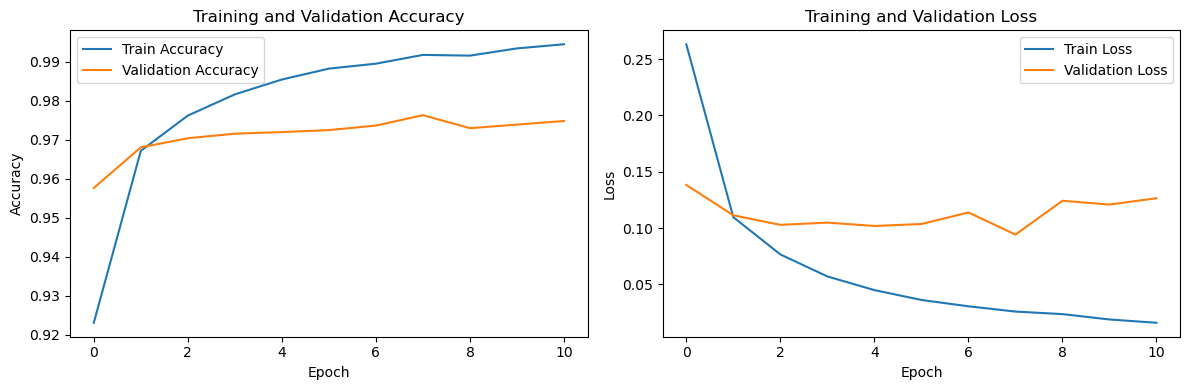

In [19]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_model.history['accuracy'], label='Train Accuracy')
plt.plot(train_model.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(train_model.history['loss'], label='Train Loss')
plt.plot(train_model.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.tight_layout()
plt.show()

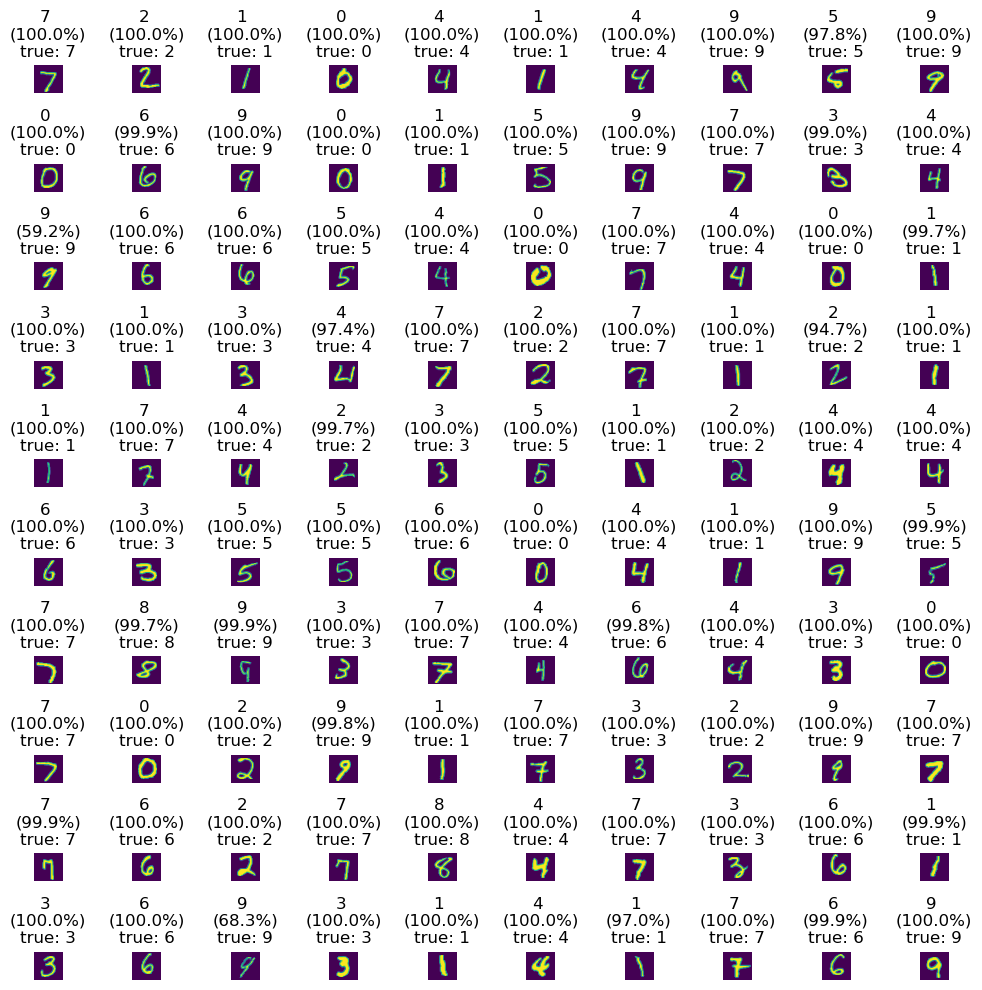

In [31]:
import numpy as np
class_names = ['0','1','2','3','4','5','6','7','8','9']

probs = model.predict(X_test[:100])
preds = np.argmax(probs,axis=-1)
confs = probs.max(axis=-1)

fig, axes = plt.subplots(10,10, figsize=(10,10))
for ax, img, p, c, t in zip(axes.ravel(), X_test[:100], preds, confs, y_test[:100]):
    pred_name = class_names[int(p)]
    true_name = class_names[int(t)]
    ax.imshow(img)
    ax.set_title(f"{pred_name} \n({c*100:.1f}%)\ntrue: {true_name}")
    ax.axis('off')
plt.tight_layout()
plt.show()



Sick 100% on almost all 

Regression problem
1. Load California housing dataset and split it to training and testing datasets.
2. Build and train a neural network for price prediction. Tune the hyperparameters and discuss the results.
3. Plot the network history.
4. Change the learning rate. Train the network again and plot the network history. Discuss the results.
5. Save the weights of the layers and use callbacks during the training process.
6. Practice saving and loading the trained model.

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
import matplotlib.pyplot